![FaMAF-UNC](https://drive.google.com/uc?export=download&id=1k4tzcXOoq6TrkDEW_Ox8o4Y4pAHzKHb7
)
> Docentes: **Damián Fernández** y **Leandro Milne**
>> Teórico del 07-05-2021


# Curvas y superficies

## Superficies

La clase pasada vimos que la esfera unitaria es una superficie regular y utilizamos un atlas de seis cartas para cubrirla.

De manera similar a lo visto para curvas, podemos tener distintas parametrizaciones para la misma superficie.

#### Ejemplo

Veamos que podemos cubrir $S=\{x\in\mathbb{R}^3 \mid \|x\|=1\}$ con sólo dos parametrizaciones (cartas). Una de ellas cubrirá $S \setminus \{p^N\}$ que es la esfera sin el polo norte $p^N = (0,0,1)$, y la otra cubrirá la esfera sin el polo sur $p^S = (0,0,-1)$. Veamos la primera de ellas, pues la segunda se define de manera análoga.

Considere un plano $\mathcal{P}$ que corta a la esfera por el ecuador, i.e., $\mathcal{P}=\{ x\in \mathbb{R}^3 \mid x_3=0\}$. Ahora para cada $x\in S \setminus \{p^N\}$ tenemos que la recta que pasa por $x$ y $p^N$ es
$$
    t \mapsto p^N + t(x-p^N) = \bigl( t x_1, t x_2, 1+t(x_3 - 1)\bigr),
$$

Note que esta recta corta al plano $\mathcal{P}$ cuando $t$ cumple $1+t(x_3 - 1) = 0$, o sea, $t=1/(1-x_3)$.


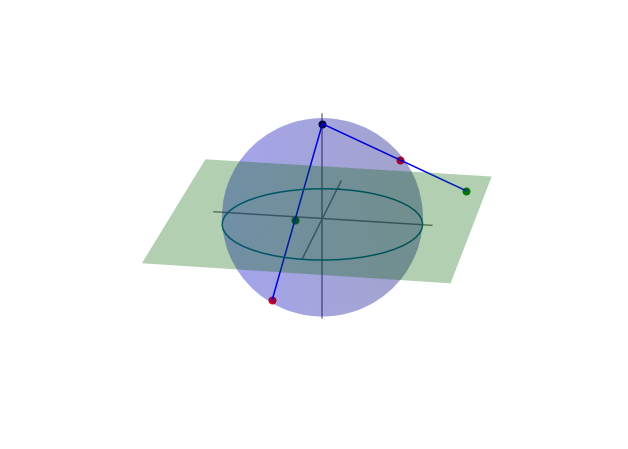

In [ ]:
#@title Proyección estereográfica { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

fig = plt.figure(figsize=(11,8))
ax = fig.add_subplot(1,1,1,projection='3d')

# ejes
ax.plot3D([0,0],[-1.1,1.1], [0,0], color=(0.5,0.5,0.5))
ax.plot3D([-1.1,1.1], [0,0], [0,0], color=(0.5,0.5,0.5))
ax.plot3D([0,0], [0,0], [-1.1,1.1], color=(0.5,0.5,0.5))
# grilla
th = np.linspace(0, 2*np.pi, 50)
ph = np.linspace(0, np.pi, 30)
x = np.outer(np.sin(ph), np.cos(th))
y = np.outer(np.sin(ph), np.sin(th))
z = np.outer(np.cos(ph), np.ones(th.shape))
# esfera
ax.plot_surface(x, y, z, color='b', alpha=0.2)
# polo norte
ax.plot3D([0],[0], [1], 'ko', markersize=7)
# punto1
i = 24
j = 15
p = np.array([x[i,j], y[i,j], z[i,j]])
ax.plot3D([p[0]],[p[1]], [p[2]], 'ro', markersize=7)
prp = np.array([p[0], p[1]])/(1-p[2])
ax.plot3D([prp[0]],[prp[1]], [0], 'go', markersize=7)
ax.plot3D([0,p[0]],[0,p[1]], [1,p[2]], 'b')
# punto2
i = 10
j = 42
q = np.array([x[i,j], y[i,j], z[i,j]])
ax.plot3D([q[0]],[q[1]], [q[2]], 'ro', markersize=7)
prq = np.array([q[0], q[1]])/(1-q[2])
ax.plot3D([prq[0]],[prq[1]], [0], 'go', markersize=7)
ax.plot3D([0,prq[0]],[0,prq[1]], [1,0], 'b')
# plano
xp, yp = np.meshgrid([-1.5,1.5],[-1.5,1.5])
ax.plot_surface(xp, yp, np.zeros(xp.shape), color='g', alpha=0.3)
ax.plot3D(x[15,:],y[15,:], z[15,:], color=(0,0.5,0.5))

ax.view_init(30,190)
ax.axis('off');
#plt.savefig("ejm_proyestereo.pdf")


Por lo tanto, la función $\psi:S \setminus \{p^N\} \to \mathbb{R}^2$ se conoce como **proyección estereográfica** y se define como
$$
    \psi(x) = \left( \frac{x_1}{1-x_3}, \frac{x_2}{1-x_3}\right).
$$
La parametrización que buscamos es la inversa de $\psi$. Por lo tanto, si $(u_1, u_2) = \psi(x)$ con $x\in S \setminus \{p^N\}$, entonces
$$
    u_1^2 + u_2^2 +1 = \frac{x_1^2 + x_2^2}{(1-x_3)^2} +1 = \frac{1-x_3^2}{(1-x_3)^2}+1
    = \frac{2-2x_3}{(1-x_3)^2} = \frac{2}{1-x_3}.
$$
Luego
$$
    x_3 = \frac{u_1^2 + u_2^2 -1}{u_1^2 + u_2^2 +1}.
$$
Además, como $u_1 = x_1/(1-x_3)$ entonces
$$
    x_1 = u_1 (1-x_3) = \frac{2 u_1}{u_1^2 + u_2^2 +1}.
$$
Por lo tanto, podemos definir $\phi:\mathbb{R}^2 \to \mathbb{R}^3$ tal que
$$
    \phi(u) = \left(\frac{2 u_1}{u_1^2 + u_2^2 +1}, \frac{2 u_2}{u_1^2 + u_2^2 +1},  \frac{u_1^2 + u_2^2 -1}{u_1^2 + u_2^2 +1}\right),
$$
donde, por construcción, $\operatorname{img}(\phi) = S \setminus \{p^N\}$.


---


Lo mismo que hemos hecho para la esfera se puede hace para todas las superficies, siempre que en nuestro problema o análisis se necesite tener a la superficie definida paramétricamente. Cuando necesitemos definir la superficie de manera explícita el siguiente resultado es de utilidad.

>**Teorema**
>
> Si $f:U\subset \mathbb{R}^2 \to \mathbb{R}$ es continuamente diferenciable en un abierto $U$, entonces $S=\operatorname{gr}(f)$ es una superficie regular.

**Demostración**

Consideremos la función $\phi: U \to \mathbb{R}^3$ tal que
$$
    \phi(x) = \bigl( x_1, x_2, f(x_1,x_2)\bigr).
$$
Por lo tanto $\phi$ es inyectiva, sobreyectiva y $\operatorname{img}(\phi) = \operatorname{gr}(f)=S$. Además, para todo $x\in U$
$$
    \phi'(x) = \left[\begin{array}{cc}
         1 & 0 \\
         0 & 1 \\
         \frac{\partial f}{\partial x_1}(x) & \frac{\partial f}{\partial x_2}(x)
    \end{array} \right],
$$
y como sus columnas son linealmente independiente, obtenemos que $S$ es una superficie regular. $\spadesuit$




El resultado anterior también nos garantiza que los vectores
$$
v^1 = \left(1, 0,  \frac{\partial f}{\partial x_1}(\bar{x}) \right),
\quad \textrm{y} \quad
v^2 = \left(0, 1,  \frac{\partial f}{\partial x_2}(\bar{x}) \right),
$$
son los generadores del plano tangente a $S=\operatorname{gr}(f)$ en el punto $\bar{p}=(\bar{x}, f(\bar{x}))$, o sea, de manera paramétrica
$$
\mathcal{T} = \{ \bar{p}  + \alpha_1 v^1 + \alpha_2 v^2 \mid \alpha \in\mathbb{R}^2\}.
$$
Ahora, tomando $p \in \mathcal{T}$ tenemos que $p_1 = \bar{p}_1 + \alpha_1$, $p_2 = \bar{p}_2 + \alpha_2$ y $p_3 = \bar{p}_3 + \alpha_1 \frac{\partial f}{\partial x_1}(\bar{x}) + \alpha_2 \frac{\partial f}{\partial x_2}(\bar{x})$. Como $\bar{p}_3 = f(\bar{x})$, obtenemos que
$$
    p_3 = f(\bar{x}) + f'(\bar{x}) \left[\begin{array}{c} p_1 - \bar{p}_1 \\ p_2 - \bar{p}_2
                                    \end{array} \right].
$$
Por lo tanto, como $\bar{x}=(\bar{p}_1,\bar{p}_2)$, si $h(x) = f(\bar{x}) + f'(\bar{x})(x-\bar{x})$, llegamos a la definición explícita del plano tangente,
$$
    \mathcal{T} = \operatorname{gr}(h).
$$
Por otro lado, podemos definir este plano implícitamente mediante
$$
\mathcal{T} = \{ p \in \mathbb{R}^3 \mid \langle v^3 , p - \bar{p} \rangle = 0\},
$$
donde $v^3$ es un vector normal al plano definido por
$$
v^3 = v^1 \times v^2 = \left(-\frac{\partial f}{\partial x_1}(\bar{x}), -\frac{\partial f}{\partial x_2}(\bar{x}), 1  \right).
$$


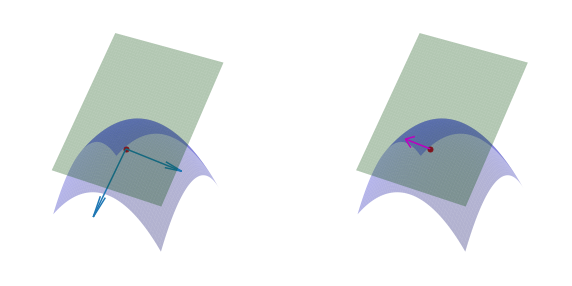

In [ ]:
#@title Plano tangente { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

t = np.linspace(-3, 3, 10)
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(1,2,1,projection='3d')
ax2 = fig.add_subplot(1,2,2,projection='3d')

# grilla
x, y = np.meshgrid(np.linspace(-1,1,50), np.linspace(-1,1,50))
z = -x**2 - y**2
ax1.plot_surface(x, y, z, color='b', alpha=0.3)
ax2.plot_surface(x, y, z, color='b', alpha=0.3)
# punto
i = 26
j = 36
p = np.array([x[i,j], y[i,j], z[i,j]])
ax1.plot3D([p[0]],[p[1]], [p[2]], 'ro', markersize=5)
ax2.plot3D([p[0]],[p[1]], [p[2]], 'ro', markersize=5)
# plano
f = p[2]
df = np.array([-2*x[i,j], -2*y[i,j]])
zp = f + df[0]*(x-p[0]) + df[1]*(x-p[1])
ax1.plot_surface(x, y, zp, color='g', alpha=0.3)
ax2.plot_surface(x, y, zp, color='g', alpha=0.3)
# flechas
ax1.quiver(p[0], p[1], p[2], 1, 0, df[0])
ax1.quiver(p[0], p[1], p[2], 0, 1, df[1])
ax2.quiver(p[0], p[1], p[2], -df[0], -df[1], 1, color='m')

ax1.view_init(30,30)
ax2.view_init(30,30)
ax1.axis('off');
ax2.axis('off');
#plt.savefig("planos_tangentes.pdf")


Recuerde que lo anterior vale si $f$ es continuamente diferenciable.

#### Ejemplo

Considere una superficie $S$ dada por el gráfico de $f:\mathbb{R}^2 \to \mathbb{R}$ tal que
$$
f(x) = \left\{\begin{array}{cc}
     \|x\|^2 \operatorname{sen}\left(\frac{1}{\|x\|} \right)& \textrm{ si } x\neq 0,  \\
     0 & \textrm{ si } x=0.
                \end{array}\right.
$$
La función es diferenciable en $\bar{x}=0$ con $\nabla f (\bar{x})=0$, pues
$$
\lim_{x \to \bar{x}} \frac{f(x) - f(\bar{x}) - \langle \nabla f (\bar{x}), x - \bar{x} \rangle }{\| x - \bar{x}\|}
= \lim_{x \to 0} \frac{f(x)}{\|x\|}
=  \lim_{x \to 0} \|x\| \operatorname{sen}\left(\frac{1}{\|x\|} \right) = 0.
$$
Sus derivadas parciales para $x \neq 0$ vienen dadas por
$$
 \frac{\partial f}{\partial x_i} (x) = 2 x_i  \operatorname{sen}\left(\frac{1}{\|x\|} \right) - \frac{x_i}{\|x\|} \cos\left(\frac{1}{\|x\|} \right),
$$
que no son continuas en el origen. Por lo tanto la función es diferenciable en todo punto pero no es continuamente diferenciable en el origen.
Note que no podemos definir un plano tangente en el origen.


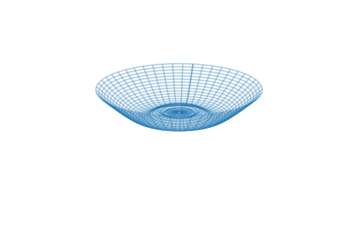

In [ ]:
#@title Suave pero sin tangente { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import warnings
warnings.filterwarnings( "ignore", module = "numpy\..*" )


fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(1,1,1,projection='3d')

# ejes
#ax.plot3D([0,0],[-0.5,0.5], [0,0], color=(0.5,0.5,0.5))
#ax.plot3D([-0.5,0.5], [0,0], [0,0], color=(0.5,0.5,0.5))
#ax.plot3D([0,0], [0,0], [-0.5,0.5], color=(0.5,0.5,0.5))
ax.plot3D([0,0], [0,0], [-0.5,0.5], 'w.')

# grilla
th = np.linspace(0, 2*np.pi, 50)
r = np.linspace(0.01, 0.5, 30)
x = np.outer(r, np.cos(th))
#x = np.array(x, dtype="object")
y = np.outer(r, np.sin(th))
#y = np.array(y, dtype="object")
z = (x**2 + y**2)*np.sin(1/np.sqrt(x**2 + y**2))
# superficie
#ax.plot_surface(x, y, z, alpha=0.2)
ax.plot_wireframe(x, y, z, alpha=0.3)
ax.view_init(30,190)
ax.axis('off');
#plt.savefig("ejm_sintangente.pdf")



Claramente, el vector normal nos genera una recta normal a $S$ que pasa por $\bar{p} = f(\bar{x})$. Esto nos permite obtener $\nabla f (\bar{x})$ de manera gráfica.

#### Ejemplo

Considere que podemos graficar una superficie regular $S$ que viene dada por el gráfico de una función $f$, o sea $S=\operatorname{gr}(f)$, pero desconocemos una expresión para definir $f$. No obstante, para un punto $\bar{p} \in S$ puedo obtener gráficamente un vector $v$ normal a $S$ en $\bar{p}$.

Como $v_3 \neq 0$, ya que al ser $S$ el gráfico de una función entonces $v$ no puede ser horizontal. Ahora, la intersección de $\bar{p}+ \alpha v$ con el plano paralelo a $x_3=-1$ que pasa por $\bar{p}$ se dá en un punto $(q_1, q_2, -1)$. Obteniendo que
$$
    \frac{\partial f}{\partial x_1}(\bar{x}) = q_1,
    \quad \textrm{y} \quad
    \frac{\partial f}{\partial x_2}(\bar{x}) = q_2,
$$
para algún $\bar{x}$ tal que $\bar{p}= (\bar{x}, f(\bar{x}))$.

Esta afirmación se justifica en el hecho que la recta normal es generada por el vector $\left(-\frac{\partial f}{\partial x_1}(\bar{x}), -\frac{\partial f}{\partial x_2}(\bar{x}), 1  \right)$ y la intersección con el plano $x_3=-1$ se tiene que dar en el punto
$$
\left(\frac{\partial f}{\partial x_1}(\bar{x}), \frac{\partial f}{\partial x_2}(\bar{x}), -1  \right).
$$

Claramente lo anterior vale si $S$ es la curva dada por una función $f:\mathbb{R} \to \mathbb{R}$.




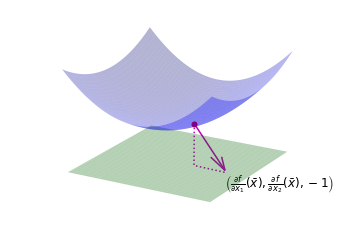

In [ ]:
#@title Vector normal { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

t = np.linspace(-3, 3, 10)
fig = plt.figure()
ax = fig.add_subplot(1,1,1,projection='3d')

# grilla
x, y = np.meshgrid(np.linspace(-1,1,50), np.linspace(-1,1,50))
z = 0.5*x**2 + y**2
ax.plot_surface(x, y, z, color='b', alpha=0.3)
# punto
i = 30
j = 25
p = np.array([x[i,j], y[i,j], z[i,j]])
ax.plot3D([p[0]],[p[1]], [p[2]], 'ro', markersize=5)
f = p[2]
df = np.array([x[i,j], 2*y[i,j]])
# flecha
ax.quiver(p[0], p[1], p[2], df[0], df[1], -1, color='m')
ax.plot3D([p[0], p[0], p[0]+df[0]], [p[1], p[1], p[1]+df[1]], [p[2], -1, -1], 'm:')

#ax.quiver(p[0], p[1], -1, df[0], df[1], 0, color='m')
ax.plot_surface(x, y, -np.ones(x.shape), color='g', alpha=0.3)
ax.text3D(p[0]+df[0], p[1]+df[1], -1, r'$\left(\frac{\partial f}{\partial x_1}(\bar{x}), \frac{\partial f}{\partial x_2}(\bar{x}), -1  \right)$', verticalalignment='top', fontsize=12)
ax.view_init(30,30)
ax.axis('off');
#plt.savefig("ejm_vecnormal.pdf")


Veamos ahora cómo definir una superficie implícitamente, o sea, cuando $S$ es una superficie de nivel. Para ello utilizaremos el Teorema de la Función Implícita, que demostraremos más adelante.

>**Teorema**
>
> Sea $f:\mathbb{R}^3 \to \mathbb{R}$ continuamente diferenciable e $\bar{y} = f(\bar{x})$ para algún $\bar{x}$ en el interior de $\operatorname{dom}(f)$. Si $S=\{ x\in \mathbb{R}^3 \mid f(x) = \bar{y} \}$ con $\nabla f (x) \neq 0$ para todo $x\in S$, entonces $S$ es una superficie regular.


**Demostración**

Sea $p \in S$ arbitrario. Como $\nabla f(p) \neq 0$, supongamos sin pérdida de generalidad que $\frac{\partial f}{\partial x_3}(p)\neq 0$. El Teorema de la Función Implícita nos garantiza que existe un abierto $W\subset\mathbb{R}^2$ tal que $(p_1,p_2) \in W$, un abierto $V\subset\mathbb{R}$ tal que $p_3 \in V$ y una función $g:W \to V$ continuamente diferenciable tal que $f\bigl(x_1,x_2, g(x_1,x_2)\bigr)=\bar{y}$ para todo $(x_1,x_2)\in W$.

De esta manera, $\operatorname{gr}(g) = (W\times V) \cap S$ es una superficie que contiene a $p$ y es regular por el Teorema anterior. $\spadesuit$





Cuando tenemos una superficie de nivel regular dada por una función $f$ como en el Teorema anterior, podemos ver que $\nabla f$ debe ser normal a esa superficie.


>**Teorema**
>
> Sea $f:\mathbb{R}^3 \to \mathbb{R}$ continuamente diferenciable y $S=\{ x\in \mathbb{R}^3 \mid f(x) = \bar{y} \}$ una superficie de nivel. Si $p \in S$ entonces $\nabla f (p)$ es normal a $S$ en $p$.


**Demostración**

Por lo visto en la demostración del Teorema anterior, existe una función continuamente diferenciable $g$ tal que $g(p_1,p_2) = p_3$ y $f\bigl(x_1, x_2, g(x_1, x_2)\bigr) = \bar{y}$ para $(x_1,x_2)$ en un entorno de $(p_1,p_2)$. Derivando, obtenemos que
$$
 0 =  f'\bigl(x_1, x_2, g(x_1, x_2)\bigr)  \left[\begin{array}{cc}
         1 & 0 \\
         0 & 1 \\
         \frac{\partial g}{\partial x_1}(x_1,x_2) & \frac{\partial g}{\partial x_2}(x_1,x_2)
    \end{array} \right].
$$
Por lo tanto, para $(x_1,x_2)=(p_1,p_2)$ tenemos
\begin{align*}
    0 &= \frac{\partial f}{\partial x_1}(p) + \frac{\partial f}{\partial x_3} (p) \frac{\partial g}{\partial x_1} (p_1,p_2)
    = \left\langle \nabla f (p), \left(1, 0, {\textstyle \frac{\partial g}{\partial x_1}(p_1,p_2) }\right)\right\rangle  \\
    0 &= \frac{\partial f}{\partial x_2}(p) + \frac{\partial f}{\partial x_3} (p) \frac{\partial g}{\partial x_2} (p_1,p_2)
    = \left\langle \nabla f (p), \left(0, 1, {\textstyle \frac{\partial g}{\partial x_2}(p_1,p_2) }\right)\right\rangle.
\end{align*}
Por lo tanto, $\nabla f(p)$ es un vector normal a $S$ en $p$. $\spadesuit$



De esta manera, si $S$ es una superficie de nivel regular dada por una función $f$, entonces su plano tangente a $\bar{p}$ viene dado por
$$
\mathcal{T} = \{ p \in \mathbb{R}^3 \mid \langle \nabla f(\bar{p}) , p - \bar{p} \rangle = 0 \},
$$






Esta propiedad nos brinda muchas aplicaciones.

#### Ejemplo

Para representar gráficamente objetos 3D es importante poder asignar un sombreado coherente. Si nuestro objeto es una superficie regular $S$, la intensidad de la luz sobre un punto $p\in S$ puede determinarse calculando el ángulo $\theta$ entre el vector normal $\nu$ y la dirección de $p$ a la fuente de luz. Asignando intensidad de luz máxima si $\cos(\theta) = 1$ y sombra total si $\cos(\theta)\leq 0$.





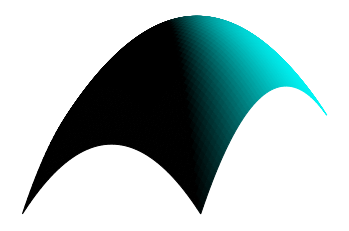

In [ ]:
#@title Iluminación { display-mode: "form" }
iluminacion = 1.5 #@param {type:"slider", min:-2, max:2, step:0.5}
import numpy as np
import matplotlib.pyplot as plt

def proy2D(x):
  # x en 3D, retorna x en 2D para graficar en el plano
  ejex=np.array([-1/np.sqrt(2),-1/np.sqrt(2)])
  ejey=np.array([1,0])
  ejez=np.array([0,1])
  return x[0]*ejex+x[1]*ejey+x[2]*ejez

fig = plt.figure()
ax = fig.add_subplot(1,1,1)

# grilla
nd = 50
x, y = np.meshgrid(np.linspace(-1,1,nd), np.linspace(-1,1,nd))
z = -x**2 - y**2
ph = iluminacion
luz = 100*np.array([np.sin(ph)*np.cos(3*np.pi/4), np.sin(ph)*np.sin(3*np.pi/4), np.cos(ph)])
for i in range(nd-1):
  for j in range(nd-1):
    p = np.array([x[i,j], y[i,j], z[i,j]])
    normalp = np.array([2*x[i,j], 2*y[i,j], 1])
    normalp = normalp/np.linalg.norm(normalp)
    luzp = (luz-p)/np.linalg.norm(luz-p)
    factor = np.maximum(0,np.inner(normalp,luzp))
    p2d1 = proy2D(p)
    p2d2 = proy2D([x[i+1,j], y[i+1,j], z[i+1,j]])
    p2d3 = proy2D([x[i+1,j+1], y[i+1,j+1], z[i+1,j+1]])
    p2d4 = proy2D([x[i,j+1], y[i,j+1], z[i,j+1]])
    ax.fill([p2d1[0], p2d2[0], p2d3[0], p2d4[0]], [p2d1[1], p2d2[1], p2d3[1], p2d4[1]], color=[0, factor, factor])
ax.axis('off');
#plt.savefig('ejm_iluminacion.pdf')


---